In [1]:
import model2_free_text_chunked_pipeline_v3 as m2fc3

In [2]:
train_df, test_df = m2fc3.prepare_train_test_data(
    "free-text.csv",
    "free-text_synthetic_realistic2.csv",
    chunk_size=50,
    test_size=0.2,
    random_state=42
)

Real raw shape: (562583, 9)
Synthetic raw shape: (562583, 9)

Real train chunks shape: (8889, 19)
Real test chunks shape: (2264, 19)
Synthetic train chunks shape: (8889, 19)
Synthetic test chunks shape: (2264, 19)

Final train shape: (17778, 19)
Final test shape: (4528, 19)

Train class counts:
label
1    8889
0    8889
Name: count, dtype: int64

Test class counts:
label
1    2264
0    2264
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = m2fc3.preprocess_train_test(train_df, test_df)


Dropping columns: ['participant', 'session', 'chunk_id']

X_train shape: (17778, 15)
X_test shape: (4528, 15)


In [4]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())
print(X_train.columns)

(17778, 15) (4528, 15)
label
1    8889
0    8889
Name: count, dtype: int64
label
1    2264
0    2264
Name: count, dtype: int64
Index(['DU_hold_mean', 'DU_hold_std', 'DD_mean', 'DD_std', 'DU_flight_mean',
       'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std',
       'total_events', 'total_time', 'avg_time_per_event', 'overall_mean',
       'overall_std'],
      dtype='object')


In [5]:
X_train_mi, X_test_mi, mi_features, mi_scores = m2fc3.select_mutual_info(
    X_train, y_train, X_test, k=10
)
X_train_mi_scaled, X_test_mi_scaled = m2fc3.scale_data(X_train_mi, X_test_mi)
mi_results = m2fc3.evaluate_models(X_train_mi_scaled, X_test_mi_scaled, y_train, y_test)


Top Mutual Information Features:
               Feature     Score
8              UU_mean  0.547346
5        DU_flight_std  0.512199
4       DU_flight_mean  0.512088
2              DD_mean  0.502698
12  avg_time_per_event  0.502520
11          total_time  0.502279
3               DD_std  0.480943
13        overall_mean  0.480042
9               UU_std  0.478192
14         overall_std  0.435082

Model: Logistic Regression
Accuracy: 0.9768109540636042

Confusion Matrix:
[[2193   71]
 [  34 2230]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      2264
           1       0.97      0.98      0.98      2264

    accuracy                           0.98      4528
   macro avg       0.98      0.98      0.98      4528
weighted avg       0.98      0.98      0.98      4528

ROC-AUC: 0.9966958633520209

Model: Linear SVM
Accuracy: 0.9776943462897526

Confusion Matrix:
[[2193   71]
 [  30 2234]]

Classification Report:
   

In [6]:
X_train_anova, X_test_anova, anova_features, anova_scores = m2fc3.select_anova(
    X_train, y_train, X_test, k=10
)
X_train_anova_scaled, X_test_anova_scaled = m2fc3.scale_data(X_train_anova, X_test_anova)
anova_results = m2fc3.evaluate_models(X_train_anova_scaled, X_test_anova_scaled, y_train, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [10] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Top ANOVA Features:
               Feature         Score        P_Value
8              UU_mean  34323.373292   0.000000e+00
13        overall_mean  15533.604222   0.000000e+00
11          total_time  15525.638372   0.000000e+00
12  avg_time_per_event  15525.638372   0.000000e+00
2              DD_mean  15525.638372   0.000000e+00
4       DU_flight_mean   4819.776150   0.000000e+00
6              UD_mean   4716.252541   0.000000e+00
14         overall_std   1264.395515  1.350676e-267
9               UU_std    995.397597  1.263096e-212
7               UD_std     37.024823   1.190246e-09

Model: Logistic Regression
Accuracy: 0.9545053003533569

Confusion Matrix:
[[2118  146]
 [  60 2204]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2264
           1       0.94      0.97      0.96      2264

    accuracy                           0.95      4528
   macro avg       0.96      0.95      0.95      4528
weighted

In [7]:
X_train_corr, X_test_corr, corr_features, corr_scores = m2fc3.select_correlation(
    X_train, y_train, X_test, k=10
)
X_train_corr_scaled, X_test_corr_scaled = m2fc3.scale_data(X_train_corr, X_test_corr)
corr_results = m2fc3.evaluate_models(X_train_corr_scaled, X_test_corr_scaled, y_train, y_test)


Top Correlation Features:
              Feature     Score
0             UU_mean  0.811669
1        overall_mean  0.682891
2  avg_time_per_event  0.682798
3          total_time  0.682798
4             DD_mean  0.682798
5      DU_flight_mean  0.461849
6             UD_mean  0.457912
7         overall_std  0.257694
8              UU_std  0.230277
9              UD_std  0.045591

Model: Logistic Regression
Accuracy: 0.9545053003533569

Confusion Matrix:
[[2118  146]
 [  60 2204]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2264
           1       0.94      0.97      0.96      2264

    accuracy                           0.95      4528
   macro avg       0.96      0.95      0.95      4528
weighted avg       0.96      0.95      0.95      4528

ROC-AUC: 0.9921429206882343

Model: Linear SVM
Accuracy: 0.9551678445229682

Confusion Matrix:
[[2114  150]
 [  53 2211]]

Classification Report:
              precisi

In [8]:
X_train_var, X_test_var, var_features, var_scores = m2fc3.select_variance(
    X_train, X_test, threshold=0.0, k=10
)
X_train_var_scaled, X_test_var_scaled = m2fc3.scale_data(X_train_var, X_test_var)
var_results = m2fc3.evaluate_models(X_train_var_scaled, X_test_var_scaled, y_train, y_test)


Top Variance Features:
          Feature       Score
0      total_time  122.715489
1          DD_std    4.662177
2     DU_hold_std    2.981348
3   DU_flight_std    2.510872
4          UD_std    2.442771
5  DU_flight_mean    0.097731
6          UU_std    0.093031
7    DU_hold_mean    0.088207
8         UD_mean    0.072318
9     overall_std    0.051366

Model: Logistic Regression
Accuracy: 0.9712897526501767

Confusion Matrix:
[[2176   88]
 [  42 2222]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2264
           1       0.96      0.98      0.97      2264

    accuracy                           0.97      4528
   macro avg       0.97      0.97      0.97      4528
weighted avg       0.97      0.97      0.97      4528

ROC-AUC: 0.995938892981558

Model: Linear SVM
Accuracy: 0.9717314487632509

Confusion Matrix:
[[2176   88]
 [  40 2224]]

Classification Report:
              precision    recall  f1-score   s

In [9]:
X_train_md, X_test_md, md_features, md_scores = m2fc3.select_mean_difference(
    X_train, y_train, X_test, k=10
)
X_train_md_scaled, X_test_md_scaled = m2fc3.scale_data(X_train_md, X_test_md)
md_results = m2fc3.evaluate_models(X_train_md_scaled, X_test_md_scaled, y_train, y_test)


Top Mean Difference Features:
              Feature      Score
0          total_time  15.127230
1             DD_mean   0.302545
2  avg_time_per_event   0.302545
3      DU_flight_mean   0.288757
4             UU_mean   0.248354
5             UD_mean   0.246277
6        overall_mean   0.220652
7              UD_std   0.142507
8              UU_std   0.140469
9         overall_std   0.116805

Model: Logistic Regression
Accuracy: 0.9545053003533569

Confusion Matrix:
[[2118  146]
 [  60 2204]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      2264
           1       0.94      0.97      0.96      2264

    accuracy                           0.95      4528
   macro avg       0.96      0.95      0.95      4528
weighted avg       0.96      0.95      0.95      4528

ROC-AUC: 0.9921429206882343

Model: Linear SVM
Accuracy: 0.9551678445229682

Confusion Matrix:
[[2114  150]
 [  53 2211]]

Classification Report:
      

In [10]:
X_train_rfe_lr, X_test_rfe_lr, rfe_lr_features = m2fc3.select_rfe_lr(
    X_train, y_train, X_test, k=10
)
X_train_rfe_lr_scaled, X_test_rfe_lr_scaled = m2fc3.scale_data(X_train_rfe_lr, X_test_rfe_lr)
rfe_lr_results = m2fc3.evaluate_models(X_train_rfe_lr_scaled, X_test_rfe_lr_scaled, y_train, y_test)


RFE Logistic Regression Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'DU_flight_std', 'UD_mean', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.980565371024735

Confusion Matrix:
[[2196   68]
 [  20 2244]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg       0.98      0.98      0.98      4528
weighted avg       0.98      0.98      0.98      4528

ROC-AUC: 0.9974977056774339

Model: Linear SVM
Accuracy: 0.9807862190812721

Confusion Matrix:
[[2195   69]
 [  18 2246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro

In [11]:
X_train_rfe_svm, X_test_rfe_svm, rfe_svm_features = m2fc3.select_rfe_svm(
    X_train, y_train, X_test, k=10
)
X_train_rfe_svm_scaled, X_test_rfe_svm_scaled = m2fc3.scale_data(X_train_rfe_svm, X_test_rfe_svm)
rfe_svm_results = m2fc3.evaluate_models(X_train_rfe_svm_scaled, X_test_rfe_svm_scaled, y_train, y_test)


RFE Linear SVM Features:
['DU_hold_mean', 'DU_hold_std', 'DD_std', 'DU_flight_mean', 'DU_flight_std', 'UD_mean', 'UU_mean', 'UU_std', 'overall_mean', 'overall_std']

Model: Logistic Regression
Accuracy: 0.980565371024735

Confusion Matrix:
[[2196   68]
 [  20 2244]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg       0.98      0.98      0.98      4528
weighted avg       0.98      0.98      0.98      4528

ROC-AUC: 0.9974977056774339

Model: Linear SVM
Accuracy: 0.9807862190812721

Confusion Matrix:
[[2195   69]
 [  18 2246]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg     

In [12]:
X_train_rfe_rf, X_test_rfe_rf, rfe_rf_features = m2fc3.select_rfe_rf(
    X_train, y_train, X_test, k=10
)
X_train_rfe_rf_scaled, X_test_rfe_rf_scaled = m2fc3.scale_data(X_train_rfe_rf, X_test_rfe_rf)
rfe_rf_results = m2fc3.evaluate_models(X_train_rfe_rf_scaled, X_test_rfe_rf_scaled, y_train, y_test)


RFE Random Forest Features:
['DD_mean', 'DU_flight_mean', 'DU_flight_std', 'UD_mean', 'UD_std', 'UU_mean', 'UU_std', 'total_time', 'avg_time_per_event', 'overall_mean']

Model: Logistic Regression
Accuracy: 0.9772526501766784

Confusion Matrix:
[[2193   71]
 [  32 2232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg       0.98      0.98      0.98      4528
weighted avg       0.98      0.98      0.98      4528

ROC-AUC: 0.9964777466318719

Model: Linear SVM
Accuracy: 0.9772526501766784

Confusion Matrix:
[[2192   72]
 [  31 2233]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg

In [13]:
X_train_sfm_lr, X_test_sfm_lr, sfm_lr_features, sfm_lr_scores = m2fc3.select_sfm_lr(
    X_train, y_train, X_test, k=10
)
X_train_sfm_lr_scaled, X_test_sfm_lr_scaled = m2fc3.scale_data(X_train_sfm_lr, X_test_sfm_lr)
sfm_lr_results = m2fc3.evaluate_models(X_train_sfm_lr_scaled, X_test_sfm_lr_scaled, y_train, y_test)


SelectFromModel Logistic Regression Features:
           Feature      Score
8          UU_mean  26.456835
4   DU_flight_mean  16.532545
14     overall_std   9.866823
0     DU_hold_mean   7.891297
9           UU_std   6.005018
6          UD_mean   3.346186
5    DU_flight_std   3.298384
1      DU_hold_std   1.419324
3           DD_std   0.386992
10    total_events   0.386214

Model: Logistic Regression
Accuracy: 0.9807862190812721

Confusion Matrix:
[[2196   68]
 [  19 2245]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg       0.98      0.98      0.98      4528
weighted avg       0.98      0.98      0.98      4528

ROC-AUC: 0.997421033163106

Model: Linear SVM
Accuracy: 0.9794611307420494

Confusion Matrix:
[[2191   73]
 [  20 2244]]

Classification Report:
              precision 

In [14]:
X_train_sfm_rf, X_test_sfm_rf, sfm_rf_features, sfm_rf_scores = m2fc3.select_sfm_rf(
    X_train, y_train, X_test, k=10
)
X_train_sfm_rf_scaled, X_test_sfm_rf_scaled = m2fc3.scale_data(X_train_sfm_rf, X_test_sfm_rf)
sfm_rf_results = m2fc3.evaluate_models(X_train_sfm_rf_scaled, X_test_sfm_rf_scaled, y_train, y_test)


SelectFromModel Random Forest Features:
               Feature     Score
8              UU_mean  0.238700
13        overall_mean  0.146142
4       DU_flight_mean  0.136230
12  avg_time_per_event  0.106836
14         overall_std  0.074674
9               UU_std  0.057734
11          total_time  0.056382
5        DU_flight_std  0.053003
2              DD_mean  0.052559
6              UD_mean  0.027969

Model: Logistic Regression
Accuracy: 0.9757067137809188

Confusion Matrix:
[[2187   77]
 [  33 2231]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2264
           1       0.97      0.99      0.98      2264

    accuracy                           0.98      4528
   macro avg       0.98      0.98      0.98      4528
weighted avg       0.98      0.98      0.98      4528

ROC-AUC: 0.9966379200014984

Model: Linear SVM
Accuracy: 0.9752650176678446

Confusion Matrix:
[[2183   81]
 [  31 2233]]

Classification Repo

In [15]:
print("MI best:\n", mi_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nANOVA best:\n", anova_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nCorrelation best:\n", corr_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nVariance best:\n", var_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nMean Difference best:\n", md_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nRFE LR best:\n", rfe_lr_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nRFE SVM best:\n", rfe_svm_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nRFE RF best:\n", rfe_rf_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nSFM LR best:\n", sfm_lr_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])
print("\nSFM RF best:\n", sfm_rf_results.iloc[0][["Model", "Accuracy", "ROC_AUC"]])

MI best:
 Model       Random Forest
Accuracy         0.993595
ROC_AUC           0.99979
Name: 2, dtype: object

ANOVA best:
 Model       Random Forest
Accuracy         0.994258
ROC_AUC          0.999422
Name: 2, dtype: object

Correlation best:
 Model       Random Forest
Accuracy         0.994258
ROC_AUC          0.999422
Name: 2, dtype: object

Variance best:
 Model       Random Forest
Accuracy         0.995804
ROC_AUC          0.999913
Name: 2, dtype: object

Mean Difference best:
 Model       Random Forest
Accuracy         0.995141
ROC_AUC          0.999511
Name: 2, dtype: object

RFE LR best:
 Model       Random Forest
Accuracy         0.994479
ROC_AUC           0.99975
Name: 2, dtype: object

RFE SVM best:
 Model       Random Forest
Accuracy         0.994479
ROC_AUC           0.99975
Name: 2, dtype: object

RFE RF best:
 Model       Random Forest
Accuracy         0.995141
ROC_AUC          0.999825
Name: 2, dtype: object

SFM LR best:
 Model       Random Forest
Accuracy         0.9

In [16]:
summary_df = m2fc3.feature_selection_summary(
    mi_features,
    anova_features,
    corr_features,
    var_features,
    md_features,
    rfe_lr_features,
    rfe_svm_features,
    rfe_rf_features,
    sfm_lr_features,
    sfm_rf_features
)

summary_df.head(15)


Feature Selection Summary:
               Feature  Times_Selected
2       DU_flight_mean              10
8               UU_std              10
0              UU_mean               9
9          overall_std               9
10             UD_mean               9
7         overall_mean               8
1        DU_flight_std               7
5           total_time               7
3              DD_mean               6
4   avg_time_per_event               6
6               DD_std               5
11              UD_std               5
12         DU_hold_std               4
13        DU_hold_mean               4
14        total_events               1


,Feature,Times_Selected
2,DU_flight_mean,10
8,UU_std,10
0,UU_mean,9
9,overall_std,9
10,UD_mean,9
7,overall_mean,8
1,DU_flight_std,7
5,total_time,7
3,DD_mean,6
4,avg_time_per_event,6


In [17]:
best_model = m2fc3.get_models()["Random Forest"]

X_train_best, X_test_best, selected_features, score_df = m2fc3.select_variance(
    X_train, X_test, threshold=0.0, k=10
)

X_train_best_scaled, X_test_best_scaled = m2fc3.scale_data(
    X_train_best, X_test_best
)

best_model.fit(X_train_best_scaled, y_train)

y_pred_best = best_model.predict(X_test_best_scaled)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)

print("Best Method: Variance + Random Forest")
print("Selected Features:", selected_features)
print("Accuracy:", (y_pred_best == y_test).mean())
print("Confusion Matrix:\n", cm)


Top Variance Features:
          Feature       Score
0      total_time  122.715489
1          DD_std    4.662177
2     DU_hold_std    2.981348
3   DU_flight_std    2.510872
4          UD_std    2.442771
5  DU_flight_mean    0.097731
6          UU_std    0.093031
7    DU_hold_mean    0.088207
8         UD_mean    0.072318
9     overall_std    0.051366
Best Method: Variance + Random Forest
Selected Features: ['total_time', 'DD_std', 'DU_hold_std', 'DU_flight_std', 'UD_std', 'DU_flight_mean', 'UU_std', 'DU_hold_mean', 'UD_mean', 'overall_std']
Accuracy: 0.995803886925795
Confusion Matrix:
 [[2247   17]
 [   2 2262]]


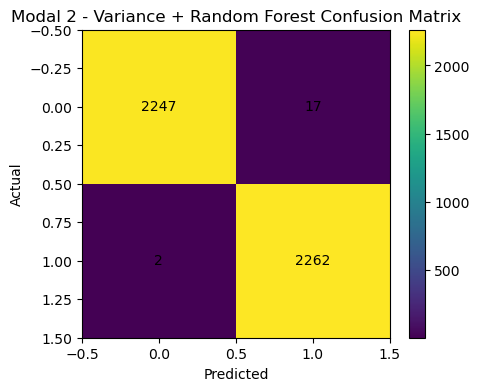

In [18]:
m2fc3.plot_confusion_matrix(cm, title="Modal 2 - Variance + Random Forest Confusion Matrix")

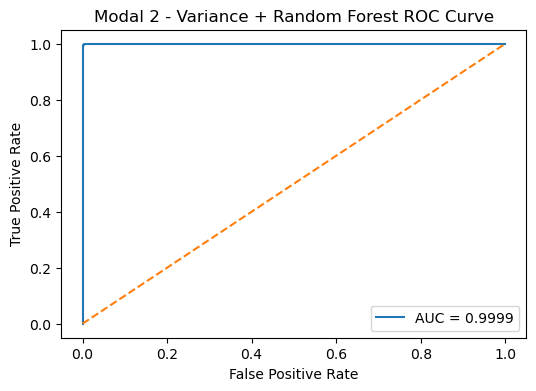

In [19]:
m2fc3.plot_roc(
    best_model,
    X_test_best_scaled,
    y_test,
    title="Modal 2 - Variance + Random Forest ROC Curve"
)


Feature: total_time
Real Mean: 14.61549080964763
Synthetic Mean: 28.51707061226043
Real Std: 33.69213948229328
Synthetic Std: 24.0397166222422


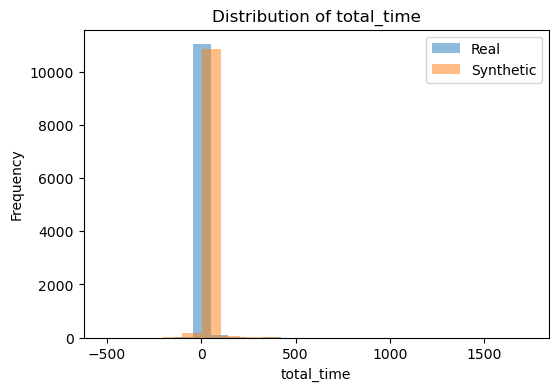


Feature: UU_mean
Real Mean: 0.292293171344033
Synthetic Mean: 0.5155087129456882
Real Std: 0.6709539960054881
Synthetic Std: 0.29881957210588495


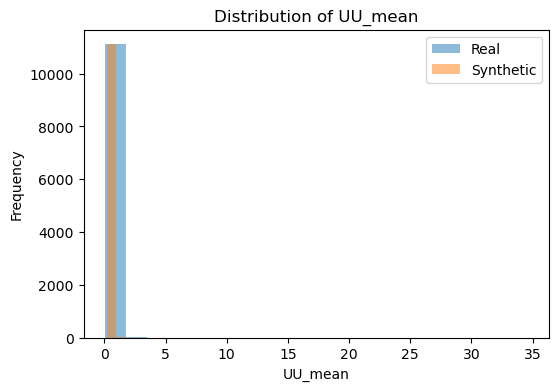

In [20]:
m2fc3.plot_feature_distribution_from_train_test(
    train_df,
    test_df,
    "total_time"
)

m2fc3.plot_feature_distribution_from_train_test(
    train_df,
    test_df,
    "UU_mean"
)